In [ ]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# ── Robot Parameters ──────────────────────────────────────
L1, L2   = 1.0, 1.0   # link lengths (m)
m1, m2   = 1.0, 1.0   # link masses (kg)
g_acc    = 9.81        # gravity (m/s²)

# ── Analytical Inverse Dynamics (our data generator) ─────
def inverse_dynamics(q1, q2, dq1, dq2, ddq1, ddq2):
    # Mass Matrix M(q)
    M11 = (m1+m2)*L1**2 + m2*L2**2 + 2*m2*L1*L2*np.cos(q2)
    M12 = m2*L2**2 + m2*L1*L2*np.cos(q2)
    M22 = m2*L2**2

    # Coriolis term  C(q, dq)·dq
    h   = m2 * L1 * L2 * np.sin(q2)
    C1  = -h * dq2**2 - 2*h * dq1 * dq2
    C2  =  h * dq1**2

    # Gravity vector g(q)
    g1  = (m1+m2)*g_acc*L1*np.cos(q1) + m2*g_acc*L2*np.cos(q1+q2)
    g2  =  m2*g_acc*L2*np.cos(q1+q2)

    # Joint torques:  τ = M·q̈ + C + g
    tau1 = M11*ddq1 + M12*ddq2 + C1 + g1
    tau2 = M12*ddq1 + M22*ddq2 + C2 + g2
    return tau1, tau2

In [ ]:
# ── Dataset Generation ─────────────────────────────────────
N = 50000   # number of training samples

# Randomly sample joint states across full operational range
q1   = np.random.uniform(-np.pi,    np.pi,    N)   # joint positions (rad)
q2   = np.random.uniform(-np.pi,    np.pi,    N)
dq1  = np.random.uniform(-2*np.pi,  2*np.pi,  N)   # joint velocities (rad/s)
dq2  = np.random.uniform(-2*np.pi,  2*np.pi,  N)
ddq1 = np.random.uniform(-10,       10,       N)   # joint accelerations (rad/s²)
ddq2 = np.random.uniform(-10,       10,       N)

# Compute ground-truth torques using analytical equations
tau1, tau2 = inverse_dynamics(q1, q2, dq1, dq2, ddq1, ddq2)

# Assemble feature matrix X and label matrix Y
X = np.column_stack([q1, q2, dq1, dq2, ddq1, ddq2])  # shape: (50000, 6)
Y = np.column_stack([tau1, tau2])                      # shape: (50000, 2)

# ── Train / Test Split ─────────────────────────────────────
X_tr, X_te, Y_tr, Y_te = train_test_split(
    X, Y, test_size=0.1, random_state=42
)

In [ ]:
# ── Build and Train the Pipeline ───────────────────────────
model = Pipeline([
    ('sc',  StandardScaler()),
    ('mlp', MLPRegressor(
                hidden_layer_sizes=(256, 256, 128),
                activation='tanh',
                max_iter=500,
                learning_rate_init=1e-3,
                random_state=42,
                verbose=True
            ))
])


model.fit(X_tr, Y_tr)

Iteration 1, loss = 216.32033718
Iteration 2, loss = 63.72256417
Iteration 3, loss = 26.84726478
Iteration 4, loss = 14.62061694
Iteration 5, loss = 9.15810492
Iteration 6, loss = 6.34640483
Iteration 7, loss = 4.63662186
Iteration 8, loss = 3.49397429
Iteration 9, loss = 2.75294917
Iteration 10, loss = 2.22128906
Iteration 11, loss = 1.76525908
Iteration 12, loss = 1.45685867
Iteration 13, loss = 1.27387778
Iteration 14, loss = 1.10211450
Iteration 15, loss = 0.93752062
Iteration 16, loss = 0.80510995
Iteration 17, loss = 0.74195655
Iteration 18, loss = 0.63440842
Iteration 19, loss = 0.56672259
Iteration 20, loss = 0.53343587
Iteration 21, loss = 0.47008796
Iteration 22, loss = 0.43472778
Iteration 23, loss = 0.40036188
Iteration 24, loss = 0.39729050
Iteration 25, loss = 0.34525137
Iteration 26, loss = 0.31026892
Iteration 27, loss = 0.30067708
Iteration 28, loss = 0.27449529
Iteration 29, loss = 0.28743420
Iteration 30, loss = 0.28167455
Iteration 31, loss = 0.27474031
Iteration 32

Pipeline(steps=[('sc', StandardScaler()),
                ('mlp',
                 MLPRegressor(activation='tanh',
                              hidden_layer_sizes=(256, 256, 128), max_iter=500,
                              random_state=42, verbose=True))])

Test RMSE  τ₁: 0.6311 Nm
Test RMSE  τ₂: 0.3734 Nm


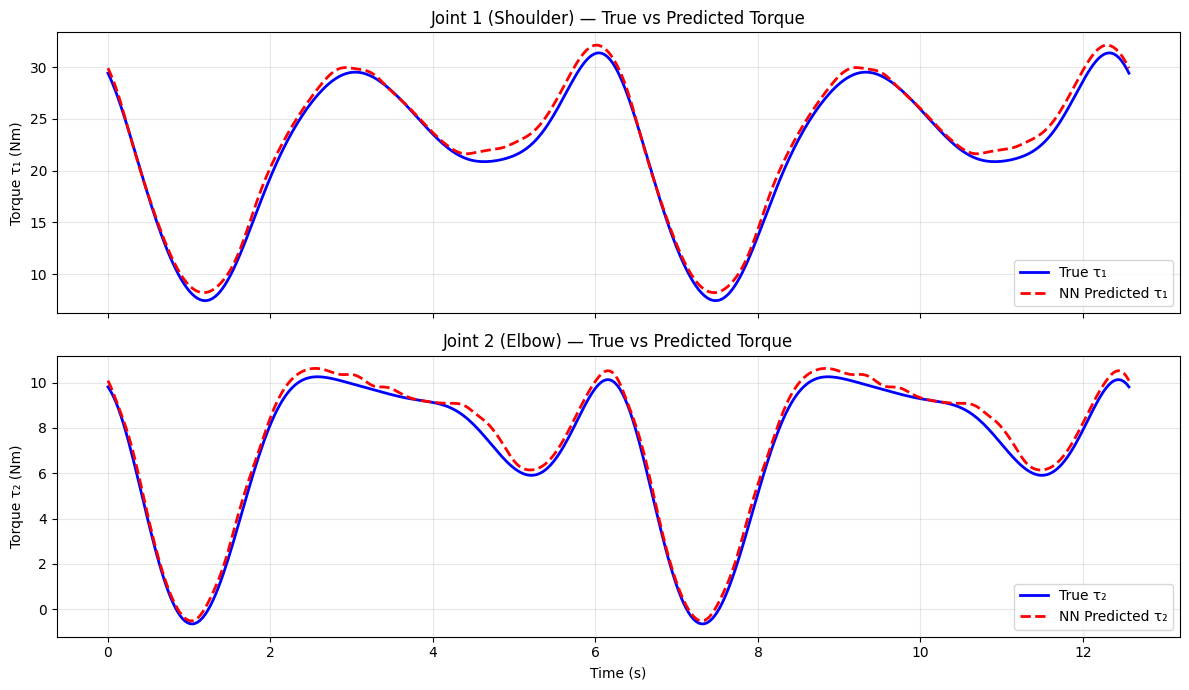

Trajectory RMSE  τ₁: 0.6872 Nm
Trajectory RMSE  τ₂: 0.3273 Nm


In [ ]:
# ── Evaluation 1: RMSE on Random Test Set ─────────────────
Y_pred = model.predict(X_te)

rmse_tau1 = np.sqrt(np.mean((Y_pred[:, 0] - Y_te[:, 0])**2))
rmse_tau2 = np.sqrt(np.mean((Y_pred[:, 1] - Y_te[:, 1])**2))
print(f"Test RMSE  τ₁: {rmse_tau1:.4f} Nm")
print(f"Test RMSE  τ₂: {rmse_tau2:.4f} Nm")

# ── Evaluation 2: Sinusoidal Trajectory Test ───────────────
# A realistic joint-space trajectory (sinusoidal excitation)
t     = np.linspace(0, 4*np.pi, 400)

q1_t  =  np.sin(t);        q2_t  =  0.5*np.sin(2*t)
dq1_t =  np.cos(t);        dq2_t =  np.cos(2*t)
ddq1_t= -np.sin(t);        ddq2_t= -2*np.sin(2*t)

# True torques from analytical model
tau1_true, tau2_true = inverse_dynamics(
    q1_t, q2_t, dq1_t, dq2_t, ddq1_t, ddq2_t
)

# Predicted torques from NN
X_traj   = np.column_stack([q1_t, q2_t, dq1_t, dq2_t, ddq1_t, ddq2_t])
Y_pred_t = model.predict(X_traj)

# ── Plot ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(t, tau1_true,       'b-',  lw=2, label='True τ₁')
ax1.plot(t, Y_pred_t[:, 0], 'r--', lw=2, label='NN Predicted τ₁')
ax1.set_ylabel('Torque τ₁ (Nm)'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title('Joint 1 (Shoulder) — True vs Predicted Torque')

ax2.plot(t, tau2_true,       'b-',  lw=2, label='True τ₂')
ax2.plot(t, Y_pred_t[:, 1], 'r--', lw=2, label='NN Predicted τ₂')
ax2.set_ylabel('Torque τ₂ (Nm)'); ax2.set_xlabel('Time (s)')
ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title('Joint 2 (Elbow) — True vs Predicted Torque')

plt.tight_layout(); plt.show()

traj_rmse1 = np.sqrt(np.mean((Y_pred_t[:,0] - tau1_true)**2))
traj_rmse2 = np.sqrt(np.mean((Y_pred_t[:,1] - tau2_true)**2))
print(f"Trajectory RMSE  τ₁: {traj_rmse1:.4f} Nm")
print(f"Trajectory RMSE  τ₂: {traj_rmse2:.4f} Nm")